In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
data=pd.read_csv("./data_cts_violent_and_sexual_crime.csv")
data.head(10)

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
0,AZE,Azerbaijan,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,155.0,CTS
1,BEL,Belgium,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,61959.0,CTS
2,BGR,Bulgaria,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,3806.0,CTS
3,BHR,Bahrain,Asia,Western Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2701.0,CTS
4,BLR,Belarus,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,4032.0,CTS
5,BMU,Bermuda,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,522.0,CTS
6,BRN,Brunei Darussalam,Asia,South-eastern Asia,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,470.0,CTS
7,CAN,Canada,Americas,Northern America,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,48135.0,CTS
8,CHE,Switzerland,Europe,Western Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,6732.0,CTS
9,CMR,Cameroon,Africa,Sub-Saharan Africa,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,2998.0,CTS/NSO


In [60]:
dataPulito=data[data["VALUE"]!=0]

In [18]:
data["Indicator"].unique()

array(['Violent offences', 'Victims of serious assault',
       'Victims of sexual violence'], dtype=object)

In [20]:
violenze=data[data["Indicator"]=='Violent offences'][["Region","Unit of measurement","VALUE"]].groupby(["Region","Unit of measurement"]).sum("VALUE")
violenze

VALUE
Region   Unit of measurement                      
Africa   Counts                       7.191780e+06
         Rate per 100,000 population  4.980145e+04
Americas Counts                       8.293793e+07
         Rate per 100,000 population  2.818899e+05
Asia     Counts                       1.630745e+07
         Rate per 100,000 population  5.339391e+04
Europe   Counts                       5.149472e+07
         Rate per 100,000 population  2.443704e+05
Oceania  Counts                       2.334724e+06
         Rate per 100,000 population  2.239873e+04

In [8]:
data["Unit of measurement"].unique()

array(['Counts', 'Rate per 100,000 population'], dtype=object)

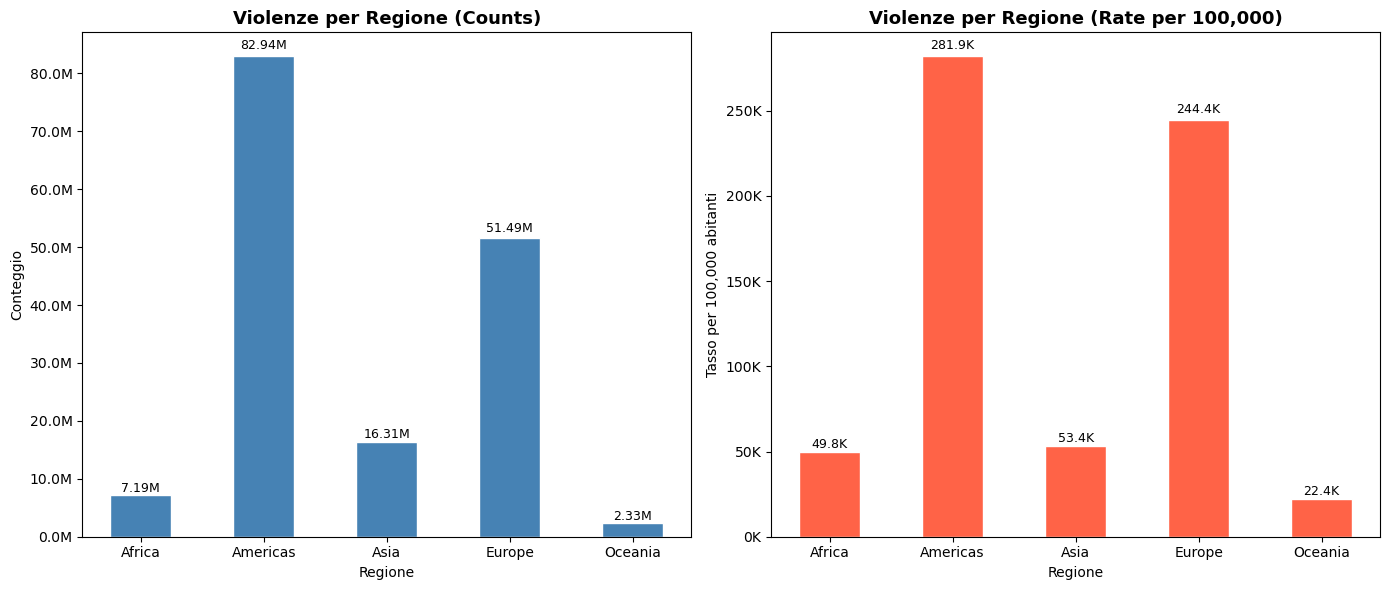

In [22]:
# Estrarre i dati dal DataFrame
counts = violenze.xs("Counts", level="Unit of measurement")["VALUE"]
rates = violenze.xs("Rate per 100,000 population", level="Unit of measurement")["VALUE"]

regioni = counts.index.tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Grafico 1: Counts ---
bars1 = ax1.bar(regioni, counts, color="steelblue", edgecolor="white", width=0.5)
ax1.set_title("Violenze per Regione (Counts)", fontsize=13, fontweight="bold")
ax1.set_xlabel("Regione")
ax1.set_ylabel("Conteggio")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# --- Grafico 2: Rate per 100,000 ---
bars2 = ax2.bar(regioni, rates, color="tomato", edgecolor="white", width=0.5)
ax2.set_title("Violenze per Regione (Rate per 100,000)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Regione")
ax2.set_ylabel("Tasso per 100,000 abitanti")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
             f"{bar.get_height()/1e3:.1f}K", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("violenze_per_regione.png", dpi=150)
plt.show()

In [24]:
data[data["Region"]=="Asia"].groupby("Region").min() #è stato un anno tabù -> questo fa pensare non che non siano avvenute violenze ma che semplicemente non ci sono state denunce fatte

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,ARE,Armenia,Central Asia,Victims of serious assault,by relationship to perpetrator,Acts intended to induce fear or emotional dist...,Female,Total,2003,Counts,0.0,CTS


In [25]:
data[data["Region"]=="Asia"].groupby("Region").max()

,Iso3_code,Country,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
Region,,,,,,,,,,,,
Asia,YEM,Yemen,Western Asia,Violent offences,by type of offence,Sexual violence: Sexual assault,Total,Total,2024,"Rate per 100,000 population",334669.0,MoI/CTS


In [49]:
data[
    (data["Region"] == "Europe") &
    ((data["Country"] == "Ukraine") | (data["Country"] == "Russian Federation"))
].groupby("Year").sum("VALUE")

,VALUE
Year,
2003,45716.425896
2004,385016.974606
2005,488356.511146
2006,491384.843298
2007,411834.673185
2008,360531.394502
2009,308185.486874
2010,249719.501979
2011,184010.657744


In [82]:
def grafico(ax,continente):
    valori=dataPulito[dataPulito["Region"]==continente].groupby("Year").sum("VALUE")
    anni=dataPulito[dataPulito["Region"]==continente]["Year"].unique()
    ax.plot(anni,valori,marker='o')

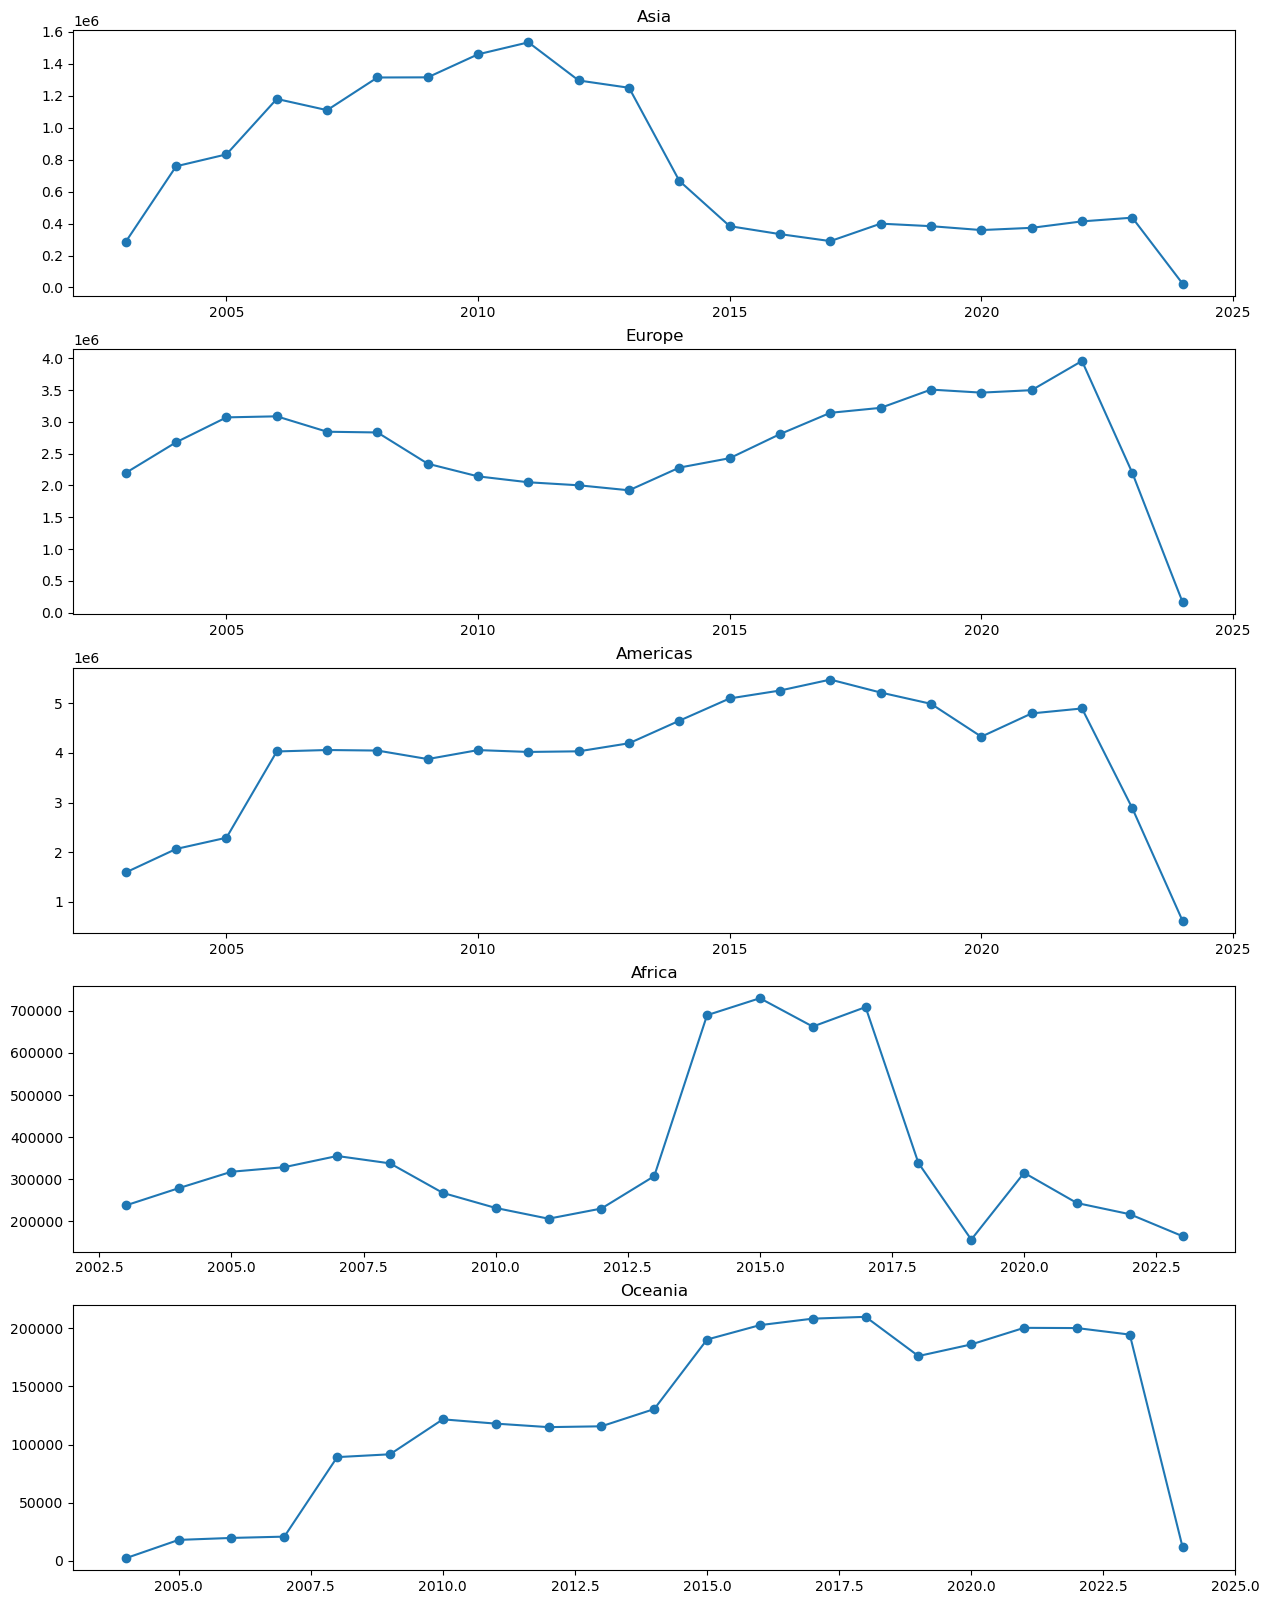

In [88]:
continenti=data["Region"].unique()
fig, axs= plt.subplots(nrows=5, figsize=(15,20))

for i,c in enumerate(continenti):
    grafico(axs[i],c)
    axs[i].set_title(c)

plt.show()

In [89]:
data["Sex"].unique()

array(['Total', 'Male', 'Female'], dtype=object)

In [94]:
data["Dimension"].unique()

array(['by type of offence', 'by relationship to perpetrator'],
      dtype=object)

In [45]:
data[data["Country"]=="Ukraine"]

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
50,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2003,Counts,5703.000000,CTS/DMDB
119,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2004,Counts,5538.000000,CTS/DMDB
207,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2005,Counts,6707.000000,CTS/DMDB
306,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2006,Counts,6464.000000,CTS/DMDB
400,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Serious assault,Total,Total,2007,Counts,5716.000000,CTS/DMDB
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30218,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2007,"Rate per 100,000 population",68.559460,CTS
30318,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2008,"Rate per 100,000 population",78.871530,CTS
30418,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2009,"Rate per 100,000 population",59.193032,CTS
30521,UKR,Ukraine,Europe,Eastern Europe,Violent offences,by type of offence,Robbery,Total,Total,2010,"Rate per 100,000 population",50.154983,CTS


## Cosa fare
- analizzare le diverse violenze [quindi le category] per 'by type of offence' ALESSIA
- analizzare le diverse violenze [quindi le category] per 'by relationship to perpetrator' REBECCA
- analizzare nei periodi di guerra continente o stati KIRTI